# EE P595 Homework 3: Identifying Malicious URLs (PyTorch)

<span style="color:red">**Released Date: February 5, 2026**</span>  
<span style="color:red">**Due Date: February 22, 2026**</span>

Build a 1D CNN to classify malicious HTTP request URLs using N-gram embeddings.

**Key Concepts:** N-gram extraction, Co-occurrence matrix, TruncatedSVD, 1D CNN

**Teammate:** _(Name if applicable)_

In [1]:
%pip install torch tqdm assertpy scikit-learn pandas matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Owner\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 1. Data Loading

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load WAF URLs dataset
df = pd.read_csv('./waf-urls.csv')
print(f'Dataset: {len(df)} URLs')

# Split: 60% train, 20% val, 20% test
urls_tv, urls_test, labels_tv, labels_test = train_test_split(
    df['url'], df['label'], test_size=0.2, random_state=12345)
urls_train, urls_vali, labels_train, labels_vali = train_test_split(
    urls_tv, labels_tv, test_size=0.25, random_state=12345)

print(f'Train: {len(urls_train)}, Val: {len(urls_vali)}, Test: {len(urls_test)}')

Dataset: 60547 URLs
Train: 36327, Val: 12110, Test: 12110


## 2. N-Gram Functions

In [3]:
from assertpy import assert_that
from tqdm import tqdm

def iter_ngrams(text, n, start_symbol='\x00', end_symbol='\x01'):
    """Generate N-grams with start/end padding."""
    ## [ TODO 1 ] Implement N-gram generation
    # - Pad (n-1) start_symbols before text
    # - Pad n end_symbols after text
    # - Return generator of N-grams
    padded = (start_symbol * (n-1)) + text + (end_symbol * n)
    return (padded[i:i+n] for i in range(len(padded) - n + 1))

# Test
assert_that(list(iter_ngrams('/test', n=3))).is_equal_to([
    '\x00\x00/', '\x00/t', '/te', 'tes', 'est', 'st\x01', 't\x01\x01', '\x01\x01\x01'
])

In [4]:
def build_ngram_mapping(urls, n, rare_threshold=2):
    """Build bidirectional N-gram to index mapping."""
    ngram_count = {}
    
    print('Counting N-grams...')
    for url in tqdm(urls):
        for ngram in iter_ngrams(url, n):
            ## [ TODO 2.1 ] Count N-gram occurrences
            ngram_count[ngram] = ngram_count.get(ngram, 0) + 1
    
    n2i, i2n = {}, []
    n_rare = 0
    
    print('Building mapping...')
    for ngram, count in tqdm(ngram_count.items()):
        ## [ TODO 2.2 ] Build mapping (only if count >= rare_threshold)
        # - Add to n2i and i2n if frequent
        # - Track n_rare for rare N-grams
        if count >= rare_threshold:
            n2i[ngram] = len(i2n)
            i2n.append(ngram)
        else:
            n_rare += 1
            
    
    print(f'Unique: {len(ngram_count)}, Kept: {len(i2n)}')
    return n2i, i2n

# Test
n2i_test, i2n_test = build_ngram_mapping(['/x', '/xyz/23', '/233'], n=3)
assert_that(len(n2i_test)).is_equal_to(5)

Counting N-grams...


100%|██████████| 3/3 [00:00<00:00, 9532.51it/s]


Building mapping...


100%|██████████| 15/15 [00:00<00:00, 170963.48it/s]

Unique: 15, Kept: 5


## 3. Co-occurrence Matrix

In [5]:
from scipy.sparse import dok_matrix

def build_cooccurrence_matrix(urls, n, n2i_mapping, window_size):
    """Build normalized co-occurrence matrix."""
    n_ngram = len(n2i_mapping)
    unknown_idx = n_ngram
    co_matrix = dok_matrix((n_ngram+1, n_ngram+1))
    
    print(f'Building co-occurrence...')
    for url in tqdm(urls):
        prev_indices = []
        for ngram in iter_ngrams(url, n):
            ## [ TODO 3.1 ] Get N-gram index (unknown_idx if not found)
            idx = n2i_mapping.get(ngram, unknown_idx)
            
            ## [ TODO 3.2 ] Update co-occurrence for prev neighbors in window
            for prev_idx in prev_indices[-window_size:]:
                co_matrix[prev_idx, idx] += 1

            prev_indices.append(idx)
    
    print('Normalizing...')
    row_sums = co_matrix.sum(axis=1)
    ## [ TODO 3.3 ] Normalize rows to probability distributions
    for (i, j) in tqdm(list(co_matrix.keys())):
        co_matrix[i, j] /= row_sums[i]
    
    return co_matrix

In [6]:
# Build N-gram mapping and co-occurrence matrix
N = 4
WINDOW_SIZE = 5

n2i_urls, i2n_urls = build_ngram_mapping(urls_train, N)
cooccurrence_urls = build_cooccurrence_matrix(urls_train, N, n2i_urls, WINDOW_SIZE)
print(f'Co-occurrence shape: {cooccurrence_urls.shape}')

Counting N-grams...


100%|██████████| 36327/36327 [00:01<00:00, 32695.58it/s]


Building mapping...


100%|██████████| 160195/160195 [00:00<00:00, 1932520.71it/s]


Unique: 160195, Kept: 82844
Building co-occurrence...


100%|██████████| 36327/36327 [05:10<00:00, 116.93it/s]


Normalizing...


100%|██████████| 1317180/1317180 [00:44<00:00, 29456.02it/s]

Co-occurrence shape: (82845, 82845)


## 4. Embedding via TruncatedSVD

In [7]:
from sklearn.decomposition import TruncatedSVD

EMBEDDING_DIMS = 10

## [ TODO 4 ] Create TruncatedSVD and fit_transform co-occurrence matrix
svd = TruncatedSVD(n_components=EMBEDDING_DIMS, n_iter=20, random_state=42)
embedding_svd = svd.fit_transform(cooccurrence_urls)

assert embedding_svd.shape == (len(n2i_urls)+1, EMBEDDING_DIMS)

## 5. PyTorch Model

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [9]:
def transform_urls(urls, padded_len, n, n2i_mapping, pad_symbol='\x01'):
    """Convert URLs to N-gram index sequences."""
    batch = np.empty((len(urls), padded_len + n), dtype=int)
    unknown_idx = len(n2i_mapping)
    
    for i, url in enumerate(urls):
        ## [ TODO 5.1 ] Pad URL to padded_len
        url = url.ljust(padded_len, pad_symbol)
        
        ## [ TODO 5.2 ] Convert N-grams to indices
        for j, ngram in enumerate(iter_ngrams(url, n)):
            batch[i, j] = n2i_mapping.get(ngram, unknown_idx)
    
    return batch

In [10]:
class URLDataset(Dataset):
    def __init__(self, urls, labels, padded_len, n, n2i_mapping):
        self.data = transform_urls(list(urls), padded_len, n, n2i_mapping)
        self.labels = labels.values.astype(np.float32)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return torch.tensor(self.data[idx], dtype=torch.long), torch.tensor(self.labels[idx])

In [11]:
class URLCNN(nn.Module):
    """1D CNN for URL classification."""
    def __init__(self, n_ngram, embedding_weights, dropout=0.25):
        super().__init__()
        embed_dim = embedding_weights.shape[1]
        
        ## [ TODO 6.1 ] Embedding layer (frozen, initialized with embedding_weights)
        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_weights),
            freeze=True
        )
        
        ## [ TODO 6.2 ] Conv blocks
        # conv1: embed_dim -> 20, kernel=5, padding=2
        # conv2: 20 -> 40, kernel=5, padding=2
        # conv3: 40 -> 80, kernel=5, padding=2
        # pool1: MaxPool1d(2), pool2: MaxPool1d(5), pool3: MaxPool1d(5)
        self.conv1 = nn.Conv1d(embed_dim, 20, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(20, 40, kernel_size=5, padding=2)
        self.conv3 = nn.Conv1d(40, 80, kernel_size=5, padding=2)
        self.pool1 = nn.MaxPool1d(2)
        self.pool2 = nn.MaxPool1d(5)
        self.pool3 = nn.MaxPool1d(5)
        self.dropout = nn.Dropout(dropout)
        
        ## [ TODO 6.3 ] FC layers
        # fc1: 160 -> 16, fc2: 16 -> 1
        self.fc1 = nn.Linear(160, 16)
        self.fc2 = nn.Linear(16, 1)
    
    def forward(self, x):
        ## [ TODO 6.4 ] Forward pass
        # Embedding -> permute -> conv blocks -> flatten -> FC -> sigmoid
        x = self.embedding(x)
        x = x.permute(0, 2, 1)

        x = self.pool1(nn.functional.relu(self.conv1(x)))   # conv blocks
        x = self.pool2(nn.functional.relu(self.conv2(x)))
        x = self.pool3(nn.functional.relu(self.conv3(x))) 
        x = self.dropout(x)

        
        x = x.flatten(start_dim=1)                          # flatten
        x = nn.functional.relu(self.fc1(x))                 # FC
        x = torch.sigmoid(self.fc2(x)).squeeze()            # sigmoid

        return x

In [12]:
# Hyperparameters
BATCH_SIZE = 256
MAX_URL_LEN = 96
N_EPOCHS = 10

# Create datasets
train_dataset = URLDataset(urls_train, labels_train, MAX_URL_LEN, N, n2i_urls)
val_dataset = URLDataset(urls_vali, labels_vali, MAX_URL_LEN, N, n2i_urls)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

model = URLCNN(len(n2i_urls), embedding_svd).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters())

In [13]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        ## [ TODO 7 ] Training step
        # optimizer.zero_grad(), forward, loss, backward, step
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y.float())
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(y)
        correct += ((out > 0.5) == y).sum().item()
        total += len(y)

    return total_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            total_loss += criterion(out, y).item() * len(y)
            correct += ((out > 0.5) == y).sum().item()
            total += len(y)
    return total_loss / total, correct / total

In [ ]:
# Training loop
history = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(N_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    history['loss'].append(train_loss)
    history['acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    print(f'Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}')

torch.save(model.state_dict(), './model-url-cnn.pt')

Epoch 1: Train Acc=0.9513, Val Acc=0.9448
Epoch 1: Train loss=0.1220, Val lossc=0.1275
Epoch 2: Train Acc=0.9530, Val Acc=0.9549
Epoch 2: Train loss=0.1180, Val lossc=0.1068
Epoch 3: Train Acc=0.9541, Val Acc=0.9566
Epoch 3: Train loss=0.1145, Val lossc=0.1043
Epoch 4: Train Acc=0.9553, Val Acc=0.9554
Epoch 4: Train loss=0.1111, Val lossc=0.1033
Epoch 5: Train Acc=0.9567, Val Acc=0.9478
Epoch 5: Train loss=0.1081, Val lossc=0.1179
Epoch 6: Train Acc=0.9562, Val Acc=0.9606
Epoch 6: Train loss=0.1074, Val lossc=0.0972
Epoch 7: Train Acc=0.9582, Val Acc=0.9590
Epoch 7: Train loss=0.1036, Val lossc=0.0979
Epoch 8: Train Acc=0.9601, Val Acc=0.9519
Epoch 8: Train loss=0.1017, Val lossc=0.1058
Epoch 9: Train Acc=0.9598, Val Acc=0.9537
Epoch 9: Train loss=0.0988, Val lossc=0.1015
Epoch 10: Train Acc=0.9602, Val Acc=0.9616
Epoch 10: Train loss=0.0985, Val lossc=0.0903


## 6. Evaluation

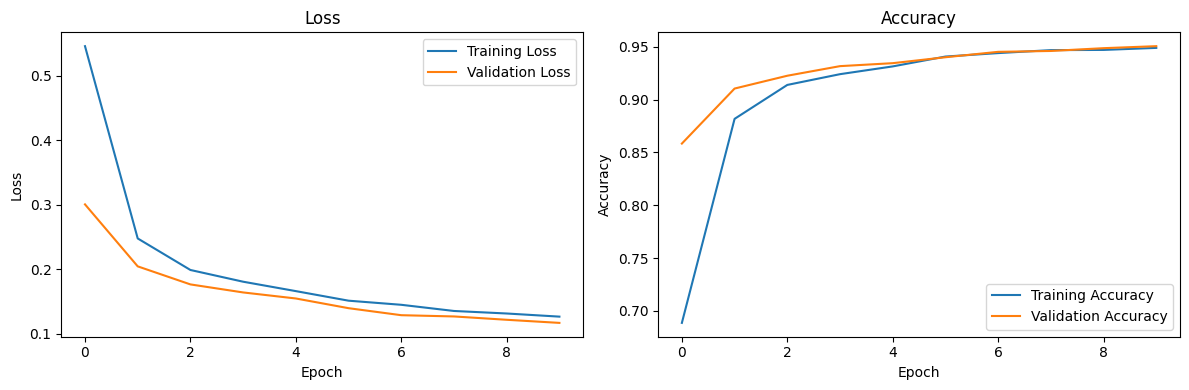

In [15]:
import matplotlib.pyplot as plt

## [ TODO 8 ] Plot loss and accuracy curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['loss'], label='Training Loss')
ax1.plot(history['val_loss'], label='Validation Loss')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(history['acc'], label='Training Accuracy')
ax2.plot(history['val_acc'], label='Validation Accuracy')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

In [17]:
from sklearn.metrics import confusion_matrix, classification_report

## [ TODO 9 ] Test evaluation
# - Create test dataset and loader
# - Predict and collect results
# - Print confusion matrix and classification report
test_dataset = URLDataset(urls_test, labels_test, MAX_URL_LEN, N, n2i_urls)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        preds = (out > 0.5).long()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# Print confusion matrix and classification report
print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds))


[[6714  429]
 [ 247 4720]]
              precision    recall  f1-score   support

         0.0       0.96      0.94      0.95      7143
         1.0       0.92      0.95      0.93      4967

    accuracy                           0.94     12110
   macro avg       0.94      0.95      0.94     12110
weighted avg       0.94      0.94      0.94     12110



## Questions

**Q1: Analyze model performance. Does lower loss indicate higher accuracy?** (2 pts)

**Your Answer:** 
Going through the epochs,  we see that the loss decreases over the epochs. This also correlates with a higher accuracy, so from the models performance it would be safe to assume that loss and accuracy are inversely correlated.


**Q2: Is large window_size (e.g., 50) good? Other compression methods?** (2 pts)

**Your Answer:**
Larger windows tend to increase noise as they capture less of the minutia in data. Because of typical length of URLs is not that large, having such a big window size would not provide meaningful information because there would be too many co-ocurrences. Other compression methods that could be used include PCA or trained Autoencoders. However, PCA is inefficient with matrices like co-occurence matrices, so it may not be useful in this case. Autoencoders can catch non-linear structures that PCA will not be able too, however it is more computationally costly.


## Submission
Submit: `homework-3-student-20260205.ipynb` + `model-url-cnn.pt`